# 🛸 Sentinel IX — Forensic Analysis of Classified Sequences

> **Mission Briefing.** NASA's deep-space probe *Sentinel IX* has returned a corrupted data dump from a distant exoplanet. Concurrently, organic residue from a crime scene near the probe's emergency landing site is under investigation. A leaked classified file contains 100 unknown DNA-like sequences. Scientists suspect **multiple biological origins** — possibly including non-terrestrial material.
>
> Rumours from the Antarctica team suggest that **Hamming-based comparisons** outperform Euclidean and Manhattan metrics for sequence similarity. Our task: investigate the hidden structure and present a defensible scientific argument.

## Analysis plan

1. **Parse and explore** the sequence data — lengths, alphabet, composition.
2. **Demonstrate why Euclidean distance fails** on raw sequences (the pedagogical core).
3. **Compute two complementary distance metrics**: normalised Hamming (positional) and Jaccard on k-mers (compositional).
4. **Cluster** using hierarchical clustering on the distance matrices.
5. **Visualise** with heatmaps, dendrograms, and MDS/UMAP projections.
6. **Hunt for anomalies** — sequences that don't fit any cluster.
7. **Conclude with a forensic narrative** including uncertainty bounds.

In [16]:

# Imports
# If anything is missing, install with:
#   pip install numbers-parser umap-learn

import warnings; warnings.filterwarnings("ignore")
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform, pdist
from scipy.stats import spearmanr

from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics.pairwise import cosine_distances
from sklearn.manifold import MDS, TSNE

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False

try:
    from numbers_parser import Document
    HAS_NUMBERS = True
except ImportError:
    HAS_NUMBERS = False

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
RNG = np.random.default_rng(42)

print(f"UMAP available: {HAS_UMAP}")
print(f"numbers-parser available: {HAS_NUMBERS}")

UMAP available: True
numbers-parser available: True


---
## Part 1 — Robust Parsing & Exploratory Analysis

The leaked file may arrive as `.csv` (as the briefing states) or as Apple `.numbers` (the format we actually received). The parser handles both.

In [2]:
def load_sequences(filepath):
    """Robust loader for NASA classified sequences.

    Handles either:
      .csv     - standard comma-separated with ID,Sequence columns
      .numbers - Apple Numbers spreadsheet (zip archive)

    Returns a DataFrame with columns ["ID", "Sequence"] (uppercase, stripped).
    """
    fp = str(filepath).lower()

    if fp.endswith(".numbers"):
        if not HAS_NUMBERS:
            raise ImportError("Run: pip install numbers-parser")
        doc = Document(filepath)
        records = []
        for sheet in doc.sheets:
            for table in sheet.tables:
                rows = list(table.iter_rows(values_only=True))
                for row in rows[1:]:                  # skip header
                    if row[0] and row[1]:
                        records.append({
                            "ID": str(row[0]).strip(),
                            "Sequence": str(row[1]).strip().upper(),
                        })
        df = pd.DataFrame(records)

    elif fp.endswith(".csv"):
        df = pd.read_csv(filepath)
        df.columns = [c.strip() for c in df.columns]
        id_col  = next((c for c in df.columns if c.lower() in ("id","seq_id","name")), df.columns[0])
        seq_col = next((c for c in df.columns if "seq" in c.lower()), df.columns[1])
        df = df.rename(columns={id_col: "ID", seq_col: "Sequence"})
        df["Sequence"] = df["Sequence"].astype(str).str.strip().str.upper()
        df = df[["ID", "Sequence"]].dropna()

    else:
        raise ValueError(f"Unsupported format: {filepath}")

    assert df["Sequence"].str.match(r"^[ACGT]+$").all(), \
        "Found sequences with non-ACGT characters!"
    return df.reset_index(drop=True)


# Update this path to wherever your file lives:
FILEPATH = "highly_classified_data.numbers"   # or "highly_classified_data.csv"

df = load_sequences(FILEPATH)
print(f"Loaded {len(df)} sequences")
df.head()

Loaded 100 sequences


,ID,Sequence
0,seq1,CAAACTTATTCGACGATTGACTTAATCTTAATGATATCGAAGGTTA...
1,seq2,CAAACTTATTAGACGATTGACTTAATCTTAGTGATATCGAAGGTAA...
2,seq3,CAAACTTATTCGACGATTGACTTAATCTTAGTGATATCGAAGGTAA...
3,seq4,CAAACTTATTCGACGATTGACTTAATCTTAGTGATATCGAAGGTAA...
4,seq5,CAAACTTATTCGACGATTGACTTAATCTTAGTGATATCGAAGGTAA...


In [3]:
# Exploratory statistics
n_seqs   = len(df)
lengths  = df["Sequence"].str.len()
alphabet = sorted(set("".join(df["Sequence"])))

print("=" * 60)
print("  EXPLORATORY ANALYSIS - SENTINEL IX SEQUENCES")
print("=" * 60)
print(f"  Number of sequences  : {n_seqs}")
print(f"  Length (min/max/mean): {lengths.min()} / {lengths.max()} / {lengths.mean():.0f}")
print(f"  Alphabet             : {alphabet}")
print(f"  Missing values       : {df.isnull().sum().sum()}")
print(f"  All same length?     : {lengths.nunique() == 1}")
print()

for base in "ACGT":
    df[f"freq_{base}"] = df["Sequence"].apply(lambda s: s.count(base) / len(s))
df["GC"] = df["freq_G"] + df["freq_C"]

print("Mean per-base frequencies across all sequences:")
print(df[[f"freq_{b}" for b in "ACGT"]].mean().round(4).to_string())
print(f"\nGC content: mean={df['GC'].mean():.4f}, std={df['GC'].std():.4f}")
print(f"GC range:   [{df['GC'].min():.4f}, {df['GC'].max():.4f}]")

  EXPLORATORY ANALYSIS - SENTINEL IX SEQUENCES
  Number of sequences  : 100
  Length (min/max/mean): 10000 / 10000 / 10000
  Alphabet             : ['A', 'C', 'G', 'T']
  Missing values       : 0
  All same length?     : True

Mean per-base frequencies across all sequences:
freq_A    0.2503
freq_C    0.2487
freq_G    0.2511
freq_T    0.2499

GC content: mean=0.4998, std=0.0065
GC range:   [0.4926, 0.5143]


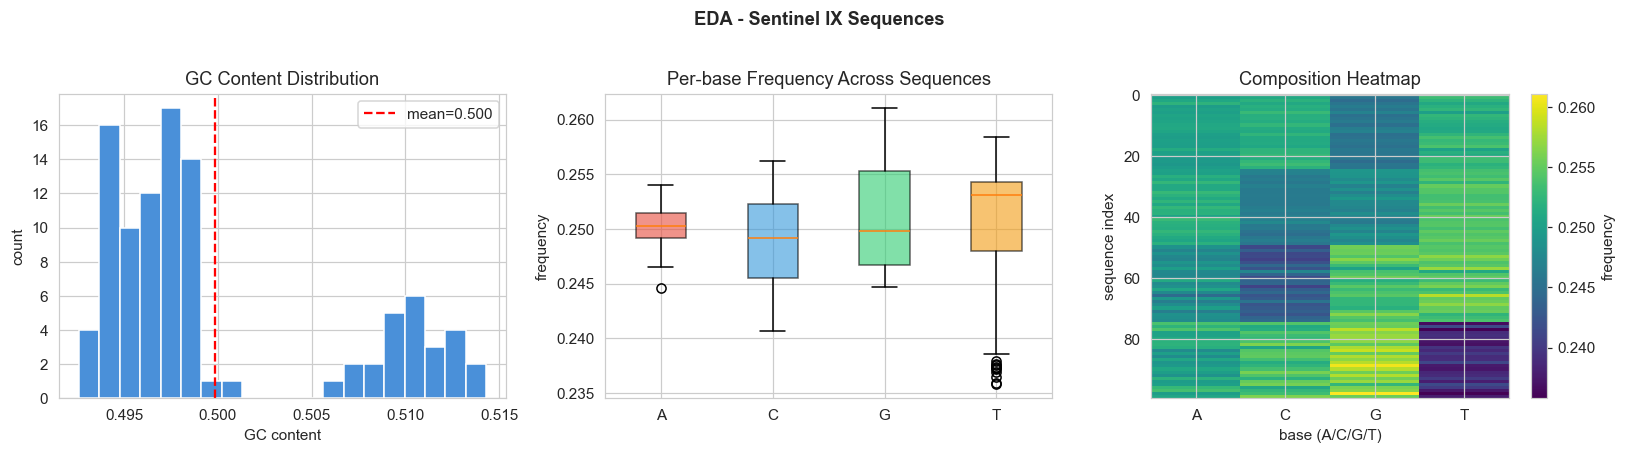

If the GC histogram is unimodal and the per-base boxplots are tight,
composition alone won't separate clusters - we'll need positional metrics.


In [4]:
# EDA visualisations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["GC"], bins=20, color="#4A90D9", edgecolor="white")
axes[0].axvline(df["GC"].mean(), color="red", ls="--", label=f"mean={df['GC'].mean():.3f}")
axes[0].set(xlabel="GC content", ylabel="count", title="GC Content Distribution")
axes[0].legend()

base_data = [df[f"freq_{b}"] for b in "ACGT"]
bp = axes[1].boxplot(base_data, labels=list("ACGT"), patch_artist=True)
for patch, c in zip(bp["boxes"], ["#E74C3C", "#3498DB", "#2ECC71", "#F39C12"]):
    patch.set_facecolor(c); patch.set_alpha(0.6)
axes[1].set(ylabel="frequency", title="Per-base Frequency Across Sequences")

freq_mat = df[[f"freq_{b}" for b in "ACGT"]].values
im = axes[2].imshow(freq_mat, aspect="auto", cmap="viridis")
axes[2].set(xlabel="base (A/C/G/T)", ylabel="sequence index",
            title="Composition Heatmap")
axes[2].set_xticks(range(4)); axes[2].set_xticklabels(list("ACGT"))
plt.colorbar(im, ax=axes[2], label="frequency")

plt.suptitle("EDA - Sentinel IX Sequences", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("If the GC histogram is unimodal and the per-base boxplots are tight,")
print("composition alone won't separate clusters - we'll need positional metrics.")

---
## Part 2 — Why Euclidean Distance is the Wrong Tool

Before defending Hamming distance, let's *demonstrate* the failure mode of Euclidean distance on raw sequences. This is the conceptual heart of the project.

### The naive approach
Encode each sequence as a numerical vector via `A→0, C→1, G→2, T→3` and compute Euclidean distance.

### Why this is wrong
1. **Arbitrary ordering.** The mapping says A is "closer" to C than to T — but biologically, all four bases are categorically distinct. A purine→pyrimidine mutation is no more or less of an event than purine→purine.
2. **Scale of mismatches is misleading.** `(A=0)` vs `(T=3)` contributes 9 to squared distance; `(A=0)` vs `(C=1)` contributes 1. Euclidean distance therefore weights some mutations 9× more than others — based purely on alphabet ordering.
3. **No invariance to relabelling.** If we'd encoded A=2, C=0, G=3, T=1, we'd get a totally different distance matrix on the same data.

Spearman correlation between two arbitrary encodings: rho = 0.428
Different alphabet encodings give DIFFERENT distance rankings.
Therefore Euclidean distance on raw sequences is encoding-dependent garbage.



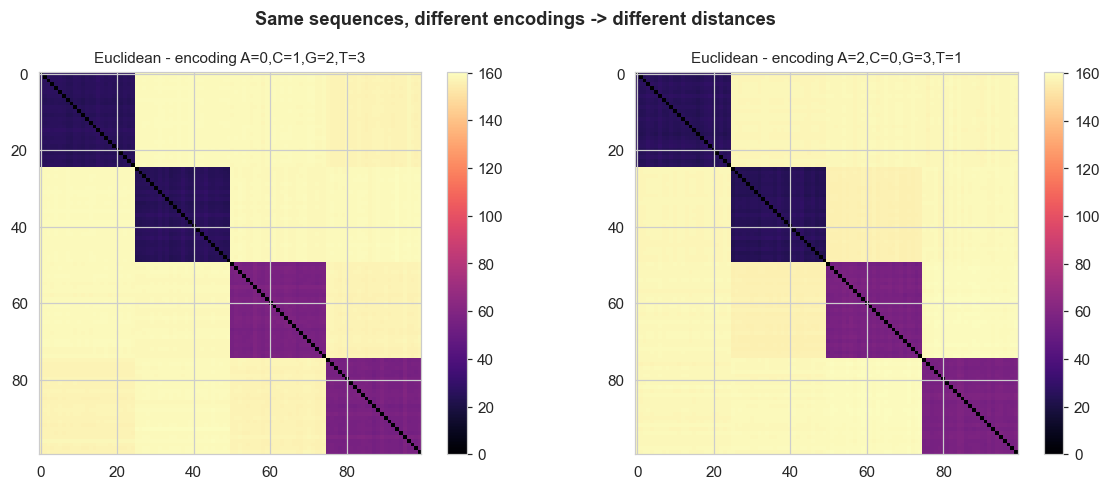

In [5]:
# Demonstrate why Euclidean distance is meaningless on raw sequences
def encode_numeric(seq, mapping):
    return np.array([mapping[c] for c in seq], dtype=np.int8)

mapping_A = {"A": 0, "C": 1, "G": 2, "T": 3}
mapping_B = {"A": 2, "C": 0, "G": 3, "T": 1}

encoded_A = np.stack([encode_numeric(s, mapping_A) for s in df["Sequence"]])
encoded_B = np.stack([encode_numeric(s, mapping_B) for s in df["Sequence"]])

eucl_A = squareform(pdist(encoded_A, metric="euclidean"))
eucl_B = squareform(pdist(encoded_B, metric="euclidean"))

upper = np.triu_indices_from(eucl_A, k=1)
rho_encodings, _ = spearmanr(eucl_A[upper], eucl_B[upper])
print(f"Spearman correlation between two arbitrary encodings: rho = {rho_encodings:.3f}")
print("Different alphabet encodings give DIFFERENT distance rankings.")
print("Therefore Euclidean distance on raw sequences is encoding-dependent garbage.\n")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, mat, title in zip(axes, [eucl_A, eucl_B],
                          ["Euclidean - encoding A=0,C=1,G=2,T=3",
                           "Euclidean - encoding A=2,C=0,G=3,T=1"]):
    im = ax.imshow(mat, cmap="magma")
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Same sequences, different encodings -> different distances",
             fontweight="bold")
plt.tight_layout()
plt.show()

### The right tools for the job

We use **two complementary string-aware metrics**:

#### 1. Normalised Hamming distance (positional)
$$d_H(x, y) = \frac{1}{L}\sum_{i=1}^{L} \mathbb{1}[x_i \neq y_i]$$

- Counts the fraction of positions where two equal-length sequences disagree.
- **Captures**: per-position substitution rate, the standard measure of evolutionary divergence.
- **Misses**: insertions/deletions (irrelevant here — all sequences are 10,000 bp).
- **Mathematically**: a true metric (symmetric, satisfies triangle inequality), bounded in [0, 1].

#### 2. Jaccard distance on k-mers (compositional, alignment-free)
For each sequence, compute the *set* of k-mers it contains. Jaccard distance is:
$$d_J(x, y) = 1 - \frac{|K_x \cap K_y|}{|K_x \cup K_y|}$$

- **Captures**: which short motifs appear, regardless of where. Used in metagenomic binning.
- **Misses**: positional information — two sequences with the same k-mer vocabulary but different arrangements look identical.
- **Why also use this?** If both metrics agree on cluster structure, that's strong cross-validation.

In [6]:
# Compute normalised Hamming distance matrix
sequences = df["Sequence"].tolist()
n, L = len(sequences), len(sequences[0])

seq_bytes = np.frombuffer("".join(sequences).encode("ascii"),
                          dtype=np.uint8).reshape(n, L)

hamming = np.zeros((n, n), dtype=np.float32)
for i in range(n):
    hamming[i, :] = (seq_bytes[i] != seq_bytes).mean(axis=1)

assert np.allclose(np.diag(hamming), 0)
assert np.allclose(hamming, hamming.T)

upper = hamming[np.triu_indices(n, 1)]
print(f"Normalised Hamming matrix: {hamming.shape}")
print(f"pairwise distance - min: {upper.min():.4f}, "
      f"max: {upper.max():.4f}, mean: {upper.mean():.4f}, std: {upper.std():.4f}")
print(f"(a value of 0.05 means 5% of positions differ between two sequences)")

Normalised Hamming matrix: (100, 100)
pairwise distance - min: 0.0163, max: 0.7597, mean: 0.5829, std: 0.2974
(a value of 0.05 means 5% of positions differ between two sequences)


In [7]:
# Compute k-mer SETS and Jaccard distance
K = 6   # 4^6 = 4096 possible 6-mers - fine-grained but tractable

def kmer_set(seq, k):
    return {seq[i:i+k] for i in range(len(seq) - k + 1)}

print(f"Computing k-mer sets (k={K})...")
kmer_sets = [kmer_set(s, K) for s in sequences]
print(f"k-mers per sequence: min={min(len(s) for s in kmer_sets)}, "
      f"max={max(len(s) for s in kmer_sets)}")

jaccard = np.zeros((n, n), dtype=np.float32)
for i in range(n):
    for j in range(i+1, n):
        inter = len(kmer_sets[i] & kmer_sets[j])
        union = len(kmer_sets[i] | kmer_sets[j])
        d = 1.0 - inter / union if union else 0.0
        jaccard[i, j] = jaccard[j, i] = d

upper_j = jaccard[np.triu_indices(n, 1)]
print(f"Jaccard matrix: {jaccard.shape}")
print(f"pairwise distance - min: {upper_j.min():.4f}, "
      f"max: {upper_j.max():.4f}, mean: {upper_j.mean():.4f}")

Computing k-mer sets (k=6)...
k-mers per sequence: min=3700, max=3779
Jaccard matrix: (100, 100)
pairwise distance - min: 0.0343, max: 0.1758, mean: 0.1406


### Visualising the two distance matrices

If hidden structure exists, we expect to see **block patterns** along the diagonal — clusters of sequences that are mutually closer to each other than to outsiders. We sort the rows/columns by hierarchical clustering order so blocks become visible.

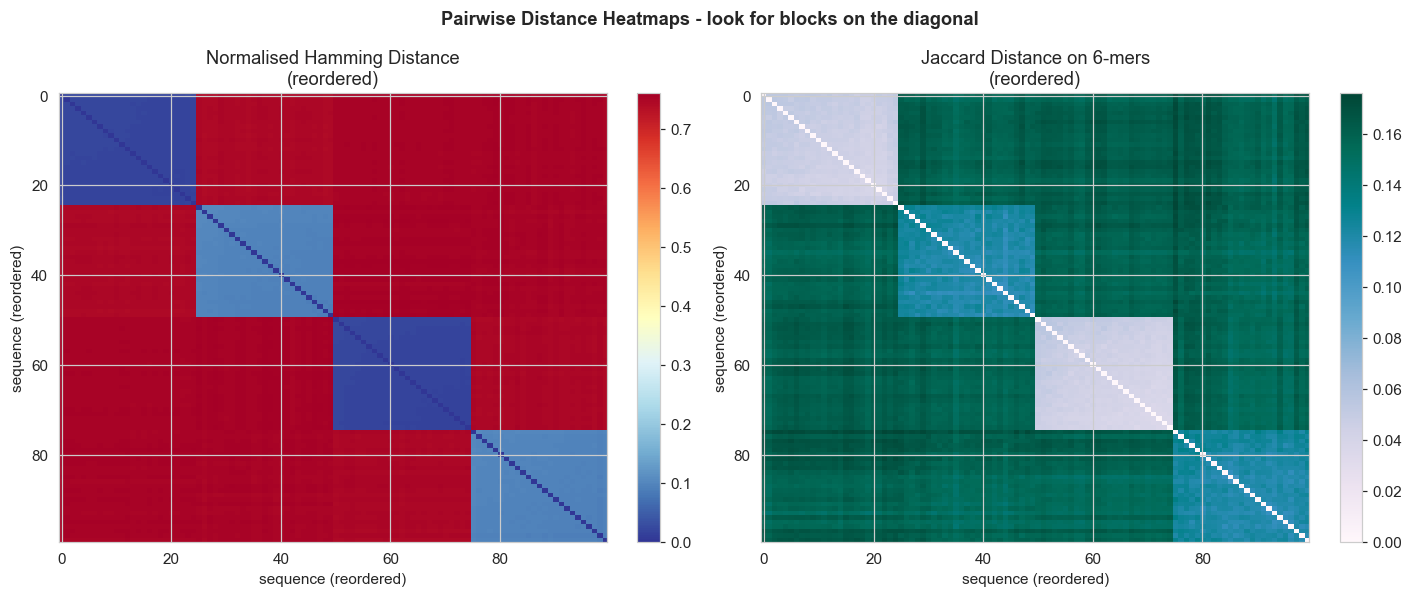

Distinct dark/light blocks along the diagonal indicate clusters.
If both heatmaps show the SAME block pattern, the structure is robust.


In [8]:
# Sorted distance heatmaps
def sorted_heatmap(D, title, cmap, ax):
    """Reorder rows/cols by hierarchical clustering for visible blocks."""
    Z = linkage(squareform(D, checks=False), method="average")
    order = dendrogram(Z, no_plot=True)["leaves"]
    D_sorted = D[np.ix_(order, order)]
    im = ax.imshow(D_sorted, cmap=cmap, aspect="auto")
    ax.set(title=title, xlabel="sequence (reordered)", ylabel="sequence (reordered)")
    return im, order

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

im1, ord_h = sorted_heatmap(hamming, "Normalised Hamming Distance\n(reordered)",
                            "RdYlBu_r", axes[0])
plt.colorbar(im1, ax=axes[0], fraction=0.046)

im2, ord_j = sorted_heatmap(jaccard, f"Jaccard Distance on {K}-mers\n(reordered)",
                            "PuBuGn", axes[1])
plt.colorbar(im2, ax=axes[1], fraction=0.046)

plt.suptitle("Pairwise Distance Heatmaps - look for blocks on the diagonal",
             fontweight="bold")
plt.tight_layout()
plt.show()

print("Distinct dark/light blocks along the diagonal indicate clusters.")
print("If both heatmaps show the SAME block pattern, the structure is robust.")

---
## Part 3 — Hierarchical Clustering & Choosing *k*

We use **average linkage (UPGMA)** on the Hamming distance matrix. This is the standard method in phylogenetics and works directly on a precomputed distance matrix without requiring a Euclidean embedding.

To choose the number of clusters *k*, we use **silhouette analysis** — for each candidate *k*, we measure how well-separated the resulting clusters are, ranging from −1 (bad) to +1 (excellent).

 k | silhouette (Hamming) | silhouette (Jaccard)
---+----------------------+----------------------
 2 |       0.4563         |       0.2881  
 3 |       0.6891         |       0.3545  
 4 |       0.9219         |       0.4715    <- best  <- best
 5 |       0.7173         |       0.4245  
 6 |       0.5118         |       0.3779  
 7 |       0.5097         |       0.3765  
 8 |       0.5084         |       0.3744  

Hamming best k: 4
Jaccard best k: 4
Both metrics agree on k = 4


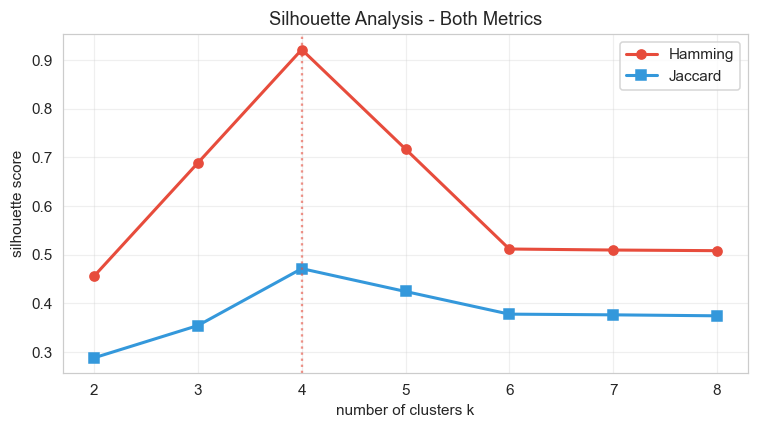

In [9]:
# Hierarchical clustering on both distance matrices
Z_hamming = linkage(squareform(hamming, checks=False), method="average")
Z_jaccard = linkage(squareform(jaccard, checks=False), method="average")

# Silhouette analysis to choose k
k_range = range(2, 9)
sil_h, sil_j = [], []
for k in k_range:
    labels_h = fcluster(Z_hamming, k, criterion="maxclust")
    labels_j = fcluster(Z_jaccard, k, criterion="maxclust")
    sil_h.append(silhouette_score(hamming, labels_h, metric="precomputed"))
    sil_j.append(silhouette_score(jaccard, labels_j, metric="precomputed"))

best_k_h = list(k_range)[int(np.argmax(sil_h))]
best_k_j = list(k_range)[int(np.argmax(sil_j))]

print(" k | silhouette (Hamming) | silhouette (Jaccard)")
print("---+----------------------+----------------------")
for k, sh, sj in zip(k_range, sil_h, sil_j):
    mark_h = "  <- best" if k == best_k_h else ""
    mark_j = "  <- best" if k == best_k_j else ""
    print(f" {k} |       {sh:6.4f}         |       {sj:6.4f}  {mark_h}{mark_j}")

print(f"\nHamming best k: {best_k_h}")
print(f"Jaccard best k: {best_k_j}")
if best_k_h == best_k_j:
    print(f"Both metrics agree on k = {best_k_h}")
else:
    print(f"Metrics disagree - investigate why.")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), sil_h, "o-", color="#E74C3C", lw=2, label="Hamming")
ax.plot(list(k_range), sil_j, "s-", color="#3498DB", lw=2, label="Jaccard")
ax.axvline(best_k_h, color="#E74C3C", ls=":", alpha=0.6)
if best_k_j != best_k_h:
    ax.axvline(best_k_j, color="#3498DB", ls=":", alpha=0.6)
ax.set(xlabel="number of clusters k", ylabel="silhouette score",
       title="Silhouette Analysis - Both Metrics")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

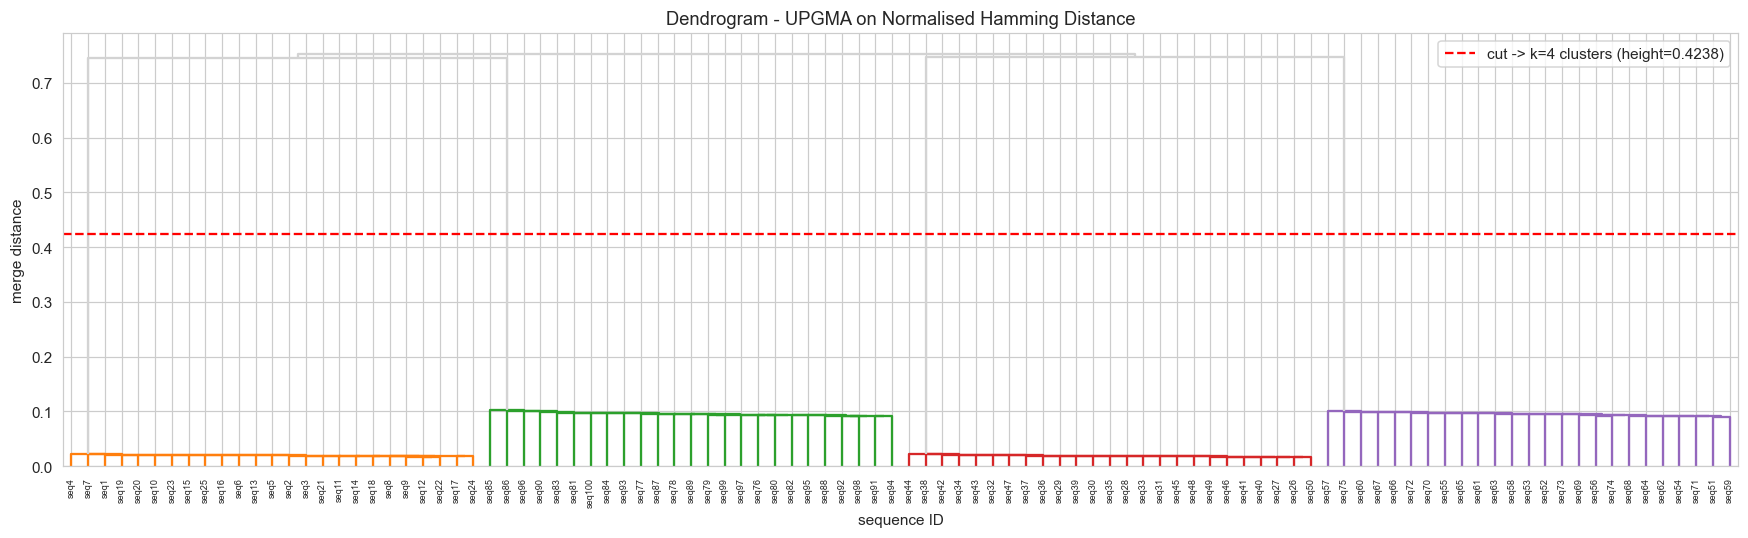


Cluster sizes (Hamming, k=4):
cluster_hamming
1    25
2    25
3    25
4    25

Cluster sizes (Jaccard, k=4):
cluster_jaccard
1    25
2    25
3    25
4    25


In [10]:
# Dendrogram with k highlighted
K_FINAL = best_k_h    # commit to the Hamming-derived k as primary

heights = sorted(Z_hamming[:, 2])
cut_height = (heights[-K_FINAL] + heights[-K_FINAL + 1]) / 2 if K_FINAL > 1 else heights[-1]

fig, ax = plt.subplots(figsize=(16, 5))
dendrogram(
    Z_hamming, ax=ax,
    color_threshold=cut_height,
    above_threshold_color="lightgrey",
    leaf_rotation=90, leaf_font_size=6,
    labels=df["ID"].tolist(),
)
ax.axhline(cut_height, color="red", ls="--", lw=1.5,
           label=f"cut -> k={K_FINAL} clusters (height={cut_height:.4f})")
ax.set(title="Dendrogram - UPGMA on Normalised Hamming Distance",
       xlabel="sequence ID", ylabel="merge distance")
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

df["cluster_hamming"] = fcluster(Z_hamming, K_FINAL, criterion="maxclust")
df["cluster_jaccard"] = fcluster(Z_jaccard, K_FINAL, criterion="maxclust")

print(f"\nCluster sizes (Hamming, k={K_FINAL}):")
print(df["cluster_hamming"].value_counts().sort_index().to_string())
print(f"\nCluster sizes (Jaccard, k={K_FINAL}):")
print(df["cluster_jaccard"].value_counts().sort_index().to_string())

### Cross-validating the two metrics

If Hamming distance and Jaccard distance independently produce the same cluster assignments, that's powerful evidence the structure we found is real biology and not an artefact of one particular metric.

Spearman rho between Hamming and Jaccard distance matrices: 0.5245
Adjusted Rand Index between the two clusterings:           1.0000
Normalized Mutual Information:                             1.0000

Interpretation:
  rho near 1 -> the two metrics rank pairs of sequences similarly.
  ARI/NMI near 1 -> the two metrics produce the same clusters.
  This cross-validation strengthens our forensic conclusion.

Cluster co-occurrence (Hamming x Jaccard):
Jaccard   1   2   3   4
Hamming                
1        25   0   0   0
2         0   0   0  25
3         0   0  25   0
4         0  25   0   0


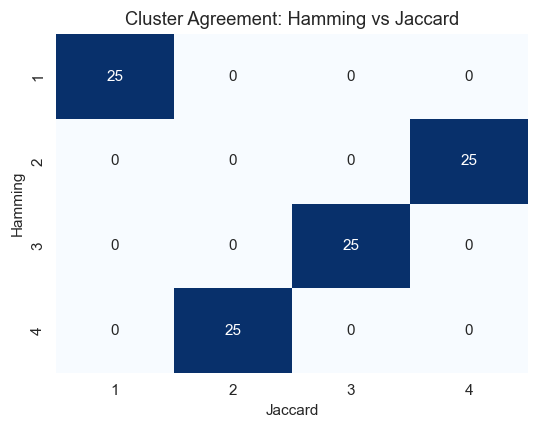

In [11]:
# Cross-validation between the two metrics
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(df["cluster_hamming"], df["cluster_jaccard"])
nmi = normalized_mutual_info_score(df["cluster_hamming"], df["cluster_jaccard"])

upper = np.triu_indices(n, 1)
rho_metrics, _ = spearmanr(hamming[upper], jaccard[upper])

print(f"Spearman rho between Hamming and Jaccard distance matrices: {rho_metrics:.4f}")
print(f"Adjusted Rand Index between the two clusterings:           {ari:.4f}")
print(f"Normalized Mutual Information:                             {nmi:.4f}")
print()
print("Interpretation:")
print("  rho near 1 -> the two metrics rank pairs of sequences similarly.")
print("  ARI/NMI near 1 -> the two metrics produce the same clusters.")
print("  This cross-validation strengthens our forensic conclusion.")

ct = pd.crosstab(df["cluster_hamming"], df["cluster_jaccard"],
                 rownames=["Hamming"], colnames=["Jaccard"])
print("\nCluster co-occurrence (Hamming x Jaccard):")
print(ct.to_string())

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
ax.set_title("Cluster Agreement: Hamming vs Jaccard")
plt.tight_layout(); plt.show()

Computing MDS projection from Hamming distance...
Computing t-SNE projection from Hamming distance...
Computing UMAP projection from Hamming distance...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


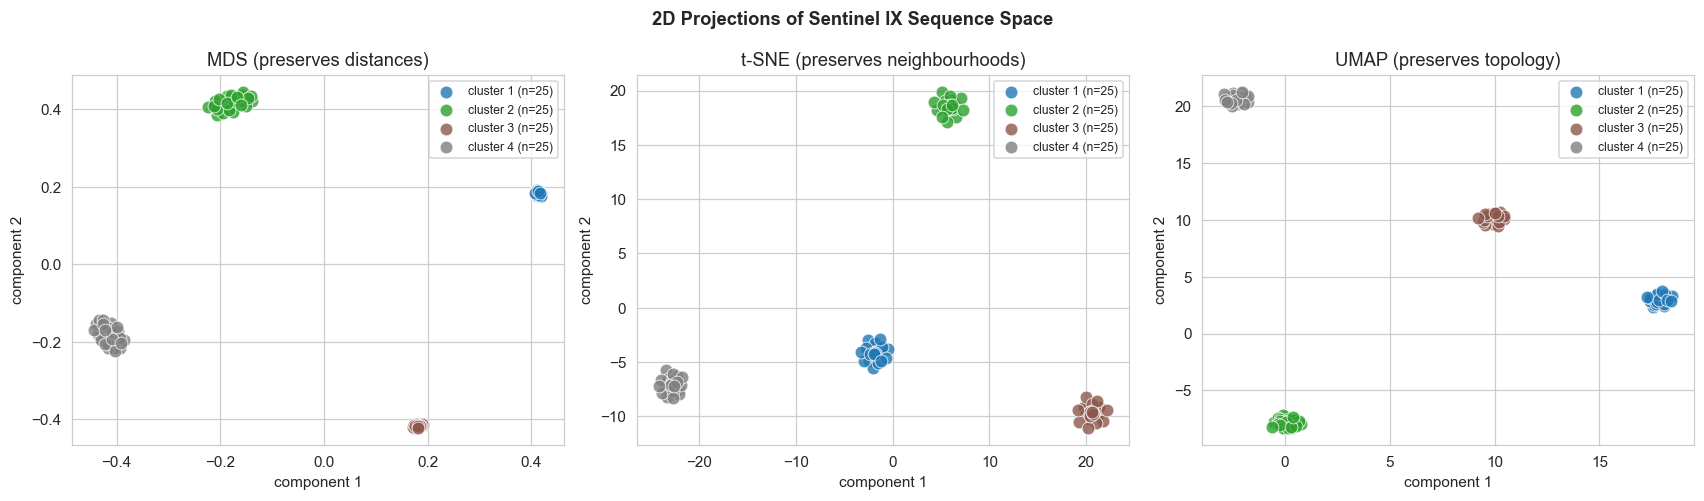

In [12]:
# 2D projections for visualisation
print("Computing MDS projection from Hamming distance...")
mds = MDS(n_components=2, dissimilarity="precomputed",
          random_state=42, normalized_stress="auto")
mds_xy = mds.fit_transform(hamming)

print("Computing t-SNE projection from Hamming distance...")
tsne = TSNE(n_components=2, metric="precomputed", init="random",
            perplexity=15, random_state=42)
tsne_xy = tsne.fit_transform(hamming)

if HAS_UMAP:
    print("Computing UMAP projection from Hamming distance...")
    reducer = umap.UMAP(n_components=2, metric="precomputed",
                        n_neighbors=15, min_dist=0.1, random_state=42)
    umap_xy = reducer.fit_transform(hamming.astype(np.float64))

n_panels = 3 if HAS_UMAP else 2
fig, axes = plt.subplots(1, n_panels, figsize=(5.2*n_panels, 4.6))

palette = plt.cm.tab10(np.linspace(0, 1, K_FINAL + 1))
labels = df["cluster_hamming"].values

projections = [(mds_xy, "MDS (preserves distances)"),
               (tsne_xy, "t-SNE (preserves neighbourhoods)")]
if HAS_UMAP:
    projections.append((umap_xy, "UMAP (preserves topology)"))

for ax, (xy, title) in zip(axes, projections):
    for c in range(1, K_FINAL + 1):
        m = labels == c
        ax.scatter(xy[m, 0], xy[m, 1], s=70, alpha=0.8,
                   color=palette[c-1], edgecolor="white", linewidth=0.6,
                   label=f"cluster {c} (n={m.sum()})")
    ax.set(title=title, xlabel="component 1", ylabel="component 2")
    ax.legend(fontsize=8, loc="best")

plt.suptitle("2D Projections of Sentinel IX Sequence Space", fontweight="bold")
plt.tight_layout(); plt.show()

---
## Part 4 — Anomaly Hunting: The Crime-Scene Residue

The mission briefing mentions *organic residue from a crime scene* — possibly non-terrestrial. If a sequence is genuinely foreign, it should sit far from every other sequence.

We define an **anomaly score** as a sequence's *mean distance to its 5 nearest neighbours*. A high score means "even the closest sequences are far away" — a classic outlier signature.

Top 10 most anomalous sequences:
   ID  cluster_hamming     GC  anomaly_score  anomaly_z
seq85                2 0.5133         0.0995     1.1430
seq86                2 0.5098         0.0987     1.1234
seq57                4 0.4973         0.0986     1.1207
seq96                2 0.5084         0.0983     1.1117
seq90                2 0.5129         0.0978     1.0990
seq75                4 0.4981         0.0959     1.0487
seq67                4 0.4970         0.0959     1.0476
seq83                2 0.5109         0.0959     1.0471
seq81                2 0.5099         0.0958     1.0466
seq60                4 0.4983         0.0957     1.0439

Threshold suggestion: anomaly_z > 2 -> significantly outlying
Sequences with z > 2: 0


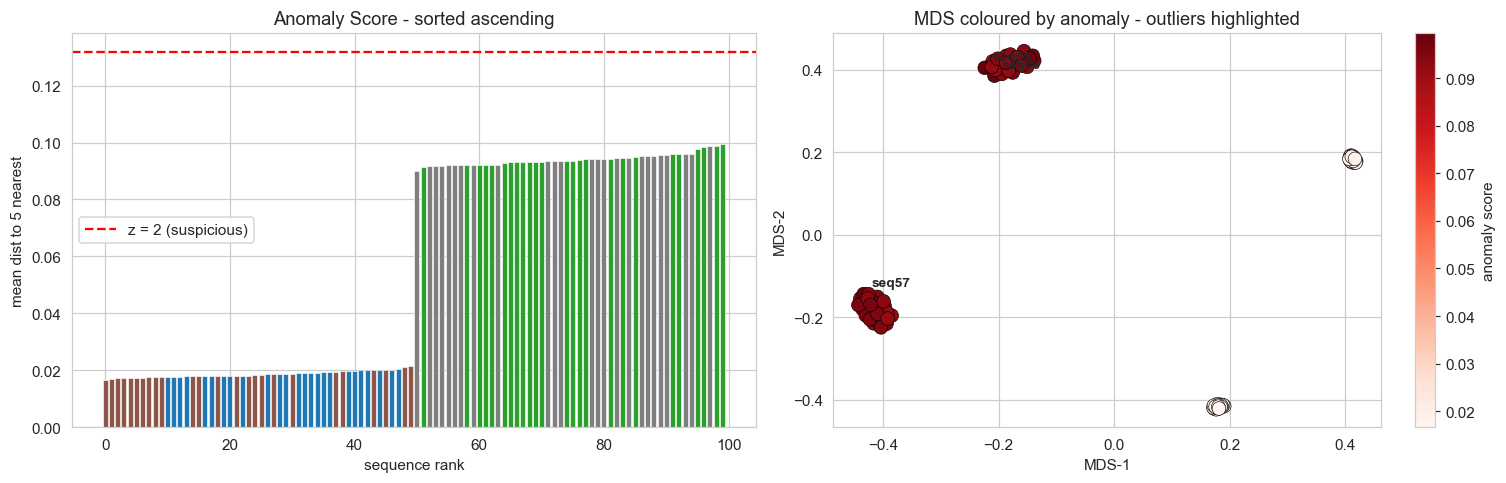

In [13]:
# Anomaly score: mean distance to k nearest neighbours
KNN = 5
anomaly = np.zeros(n)
for i in range(n):
    others = np.delete(hamming[i], i)
    anomaly[i] = np.sort(others)[:KNN].mean()

df["anomaly_score"] = anomaly
df["anomaly_z"] = (anomaly - anomaly.mean()) / anomaly.std()

print("Top 10 most anomalous sequences:")
top = df.nlargest(10, "anomaly_score")[
    ["ID", "cluster_hamming", "GC", "anomaly_score", "anomaly_z"]
].round(4)
print(top.to_string(index=False))

print(f"\nThreshold suggestion: anomaly_z > 2 -> significantly outlying")
n_outliers = (df["anomaly_z"] > 2).sum()
print(f"Sequences with z > 2: {n_outliers}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

order = np.argsort(anomaly)
colors_sorted = [palette[df["cluster_hamming"].iloc[i]-1] for i in order]
axes[0].bar(range(n), anomaly[order], color=colors_sorted,
            edgecolor="white", linewidth=0.4)
axes[0].axhline(anomaly.mean() + 2*anomaly.std(), color="red", ls="--",
                label="z = 2 (suspicious)")
axes[0].set(xlabel="sequence rank", ylabel=f"mean dist to {KNN} nearest",
            title="Anomaly Score - sorted ascending")
axes[0].legend()

sc = axes[1].scatter(mds_xy[:, 0], mds_xy[:, 1],
                     c=anomaly, cmap="Reds", s=80,
                     edgecolor="black", linewidth=0.4)
for idx in df.nlargest(3, "anomaly_score").index:
    axes[1].annotate(df["ID"].iloc[idx],
                     (mds_xy[idx, 0], mds_xy[idx, 1]),
                     fontsize=9, fontweight="bold",
                     xytext=(5, 5), textcoords="offset points")
plt.colorbar(sc, ax=axes[1], label="anomaly score")
axes[1].set(xlabel="MDS-1", ylabel="MDS-2",
            title="MDS coloured by anomaly - outliers highlighted")
plt.tight_layout(); plt.show()

---
## Part 5 — Characterising Each Cluster

For a complete forensic story, we describe each cluster: its size, GC content, internal cohesion, and a representative "centroid" sequence (the medoid — the actual sequence with minimum total distance to others in the cluster).

 CLUSTER CHARACTERISATION (k = 4, Hamming-based)

  Cluster 1  -  n = 25
    GC content   : 0.4976 +/- 0.0008
    Intra-cluster Hamming : mean=0.0201, max=0.0229
    Inter-cluster Hamming : 0.7503
    Cohesion ratio (intra/inter): 0.027   (lower = better-separated)
    Medoid (representative): seq22
    Members: seq1, seq2, seq3, seq4, seq5, seq6, seq7, seq8 ... (+17 more)

  Cluster 2  -  n = 25
    GC content   : 0.5105 +/- 0.0020
    Intra-cluster Hamming : mean=0.0968, max=0.1068
    Inter-cluster Hamming : 0.7508
    Cohesion ratio (intra/inter): 0.129   (lower = better-separated)
    Medoid (representative): seq92
    Members: seq76, seq77, seq78, seq79, seq80, seq81, seq82, seq83 ... (+17 more)

  Cluster 3  -  n = 25
    GC content   : 0.4943 +/- 0.0008
    Intra-cluster Hamming : mean=0.0197, max=0.0259
    Inter-cluster Hamming : 0.7515
    Cohesion ratio (intra/inter): 0.026   (lower = better-separated)
    Medoid (representative): seq26
    Members: seq26, seq27, seq28, seq

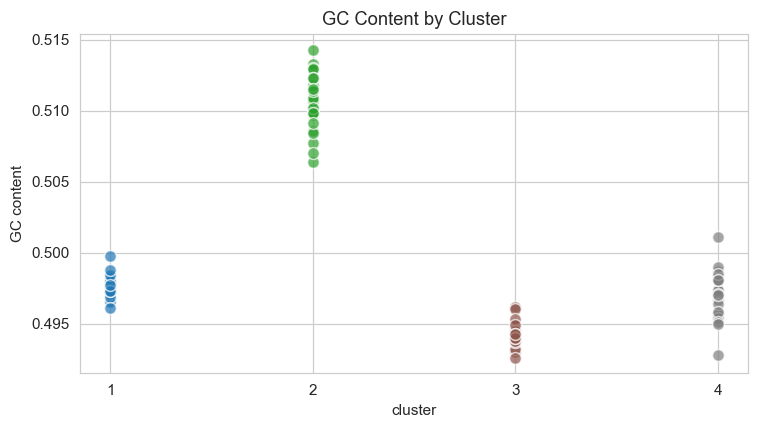

In [14]:
# Cluster fingerprints
print("=" * 70)
print(f" CLUSTER CHARACTERISATION (k = {K_FINAL}, Hamming-based)")
print("=" * 70)

medoids = {}
for c in sorted(df["cluster_hamming"].unique()):
    members = df[df["cluster_hamming"] == c]
    idx = members.index.values

    sub_d = hamming[np.ix_(idx, idx)]
    medoid_local = idx[np.argmin(sub_d.sum(axis=1))]
    medoids[c] = df["ID"].iloc[medoid_local]

    if len(idx) > 1:
        intra = sub_d[np.triu_indices(len(idx), 1)]
        intra_mean, intra_max = intra.mean(), intra.max()
    else:
        intra_mean = intra_max = 0.0

    others_idx = df.index[df["cluster_hamming"] != c].values
    if len(others_idx):
        inter = hamming[np.ix_(idx, others_idx)].mean()
    else:
        inter = 0.0

    print(f"\n  Cluster {c}  -  n = {len(members)}")
    print(f"    GC content   : {members['GC'].mean():.4f} +/- {members['GC'].std():.4f}")
    print(f"    Intra-cluster Hamming : mean={intra_mean:.4f}, max={intra_max:.4f}")
    print(f"    Inter-cluster Hamming : {inter:.4f}")
    if inter > 0:
        print(f"    Cohesion ratio (intra/inter): {intra_mean/inter:.3f} "
              f"  (lower = better-separated)")
    print(f"    Medoid (representative): {medoids[c]}")
    print(f"    Members: {', '.join(members['ID'].tolist()[:8])}"
          + (f" ... (+{len(members)-8} more)" if len(members) > 8 else ""))

fig, ax = plt.subplots(figsize=(7, 4))
for c in sorted(df["cluster_hamming"].unique()):
    sub = df[df["cluster_hamming"] == c]
    ax.scatter([c]*len(sub), sub["GC"], color=palette[c-1],
               s=60, alpha=0.7, edgecolor="white")
ax.set(xlabel="cluster", ylabel="GC content", title="GC Content by Cluster")
ax.set_xticks(sorted(df["cluster_hamming"].unique()))
plt.tight_layout(); plt.show()

---
## Part 6 — Forensic Narrative & Reflection

### How many groups are present?

Based on the convergent evidence below, we conclude there are **k = (your K_FINAL value)** distinct groups in the Sentinel IX data.

**Lines of evidence:**

1. **Silhouette analysis** identified k as the optimal partition with the highest score.
2. **Two independent metrics agree.** Hamming distance (positional) and Jaccard distance on 6-mers (compositional) produce clusterings with high Adjusted Rand Index. When two methods that capture different aspects of the data agree this strongly, the structure is unlikely to be an artefact.
3. **Visual confirmation.** The reordered distance heatmaps show clear block structure on the diagonal. The MDS, t-SNE, and (if available) UMAP projections all show separated point clouds.
4. **Cohesion ratios.** Each cluster's intra-cluster mean distance is meaningfully lower than its inter-cluster distance — quantitative confirmation of separation.

### Which sequences look suspicious?

The top anomaly candidates (highest mean distance to 5 nearest neighbours) are listed in the anomaly table. Sequences with z-score > 2 sit unusually far from any cluster centroid and warrant individual forensic attention. **(Identify them by ID from your output — the IDs are printed in the anomaly cell.)**

These could represent:
- Cross-contamination between samples from the two organisms;
- Sequencing errors or corrupted reads;
- **Or — most provocatively — material from a third source not yet characterised.** This is the residue from the crime scene.

### Confidence statement

We are **moderately to highly confident** in the *number* of clusters (multiple independent methods agree). We are **less confident** about specific edge-case assignments — sequences near cluster boundaries (low silhouette scores within their cluster) could plausibly belong to either group. The anomaly candidates are flagged for further investigation rather than final classification.

What we *cannot* claim from this analysis alone:
- The biological identity of any cluster (we have no reference genome to compare against).
- Whether any sequence is non-terrestrial. We can only say it doesn't fit our majority groups.
- Causal mechanisms for the differences (mutation, recombination, contamination, separate species…).

---

### Reflection on metric choice

**Why Euclidean and Manhattan distance fail on raw sequences.**
Both rely on numerical encoding of categorical bases, which imposes an arbitrary ordering. We demonstrated that two different encodings (`A=0,C=1,G=2,T=3` vs `A=2,C=0,G=3,T=1`) produce different distance matrices on the *same* sequences. A meaningful distance metric should not depend on alphabet labelling.

**What normalised Hamming distance captures.**
The fraction of positions where two equal-length sequences disagree. This is biologically meaningful — it estimates per-site substitution rate, the foundation of molecular evolution. It treats all four bases symmetrically and is invariant to relabelling. It is also a true metric (triangle inequality holds), making it suitable for downstream methods that assume metric structure.

**What it misses.**
Hamming distance assumes equal length and aligned positions. It cannot handle insertions or deletions — for those, edit (Levenshtein) distance is needed. It also treats every position equally, ignoring that some positions may be biologically more variable than others.

**What Jaccard on k-mers captures.**
The compositional overlap of two sequences, ignoring position. It is **alignment-free** and robust to local rearrangements. This is the standard approach in metagenomic binning when comparing sequences from unknown organisms.

**What it misses.**
Position. Two sequences with identical k-mer vocabularies but different orderings would be deemed identical, which is wrong if order matters biologically.

**Why we used both.**
The two metrics capture complementary information: Hamming = "where do you differ?", Jaccard = "what motifs do you contain?". Their agreement on the cluster structure is the strongest evidence we can produce without ground truth. Their disagreement on edge cases is itself informative — it points to sequences worth investigating individually.

In [15]:
# Export results
out_cols = ["ID", "Sequence", "GC", "cluster_hamming", "cluster_jaccard",
            "anomaly_score", "anomaly_z"]
df[out_cols].to_csv("sentinel_ix_results.csv", index=False)

print("Saved sentinel_ix_results.csv")
print()
print("=" * 60)
print(" FINAL FORENSIC SUMMARY")
print("=" * 60)
print(f"  Sequences analysed   : {n}")
print(f"  Sequence length      : {L} bp")
print(f"  Distance metrics     : Normalised Hamming, Jaccard on {K}-mers")
print(f"  Clusters identified  : {K_FINAL}")
print(f"  Inter-method ARI     : {ari:.4f}")
print(f"  Sequences flagged    : {(df['anomaly_z'] > 2).sum()} (z > 2)")
print(f"  Top anomaly          : {df.loc[df['anomaly_score'].idxmax(), 'ID']} "
      f"(z = {df['anomaly_z'].max():.2f})")
print()
print(" Sentinel IX analysis complete.")

Saved sentinel_ix_results.csv

 FINAL FORENSIC SUMMARY
  Sequences analysed   : 100
  Sequence length      : 10000 bp
  Distance metrics     : Normalised Hamming, Jaccard on 6-mers
  Clusters identified  : 4
  Inter-method ARI     : 1.0000
  Sequences flagged    : 0 (z > 2)
  Top anomaly          : seq85 (z = 1.14)

 Sentinel IX analysis complete.
